In [207]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [208]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv", encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [209]:
df.shape

(5572, 5)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


**Data Cleaning**

In [211]:
#removing un-wanted cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [212]:
#renaming the cols headings
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3874,ham,Okie but i scared u say i fat... Then u dun wa...
3326,ham,what number do u live at? Is it 11?
4203,ham,How are you enjoying this semester? Take care ...
2190,ham,"Ooh, 4got, i'm gonna start belly dancing in mo..."
4085,ham,Lemme know when you're here


In [213]:
#replacing target values with 0 and 1
from sklearn.preprocessing import LabelEncoder
en = LabelEncoder()
df['target']=en.fit_transform(df['target'])
df.sample(3)

,target,text
2349,0,Yar else i'll thk of all sorts of funny things.
5117,0,Aslamalaikkum....insha allah tohar beeen muht ...
3714,0,"I am late,so call you tomorrow morning.take ca..."


In [214]:
#checking for missing and duplicate values
df.isnull().sum()

target    0
text      0
dtype: int64

In [215]:
df.duplicated().sum()

np.int64(403)

In [216]:
#dealing with duplicates
df = df.drop_duplicates(keep='first')

In [217]:
#checking shape after removing duplicates
df.shape

(5169, 2)

In [218]:
df.duplicated().sum()

np.int64(0)

**EDA** Exploratory Data Analysis

In [219]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

0- not spam
1 - spam

([<matplotlib.patches.Wedge at 0x7964a57b5f10>,
 [Text(-1.014499732282844, 0.4251944181172162, 'not spam'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')])

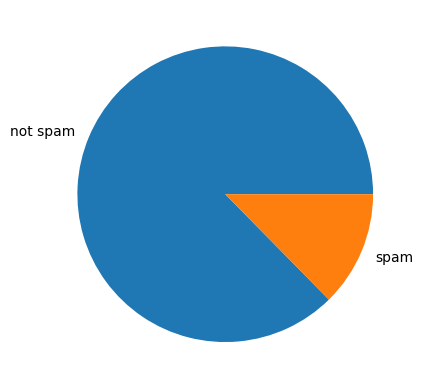

In [220]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['not spam','spam'])

here dataset is imbalanced 

In [221]:
import nltk

In [222]:
#number of characters
df['num_of_characters']=df['text'].apply(len)

In [223]:
df.sample(3)

,target,text,num_of_characters
2731,0,Mm feeling sleepy. today itself i shall get th...,53
3948,0,HMM yeah if your not too grooved out! And im l...,83
2744,0,"Tick, tick, tick ... Babe",25


In [224]:
#no.of words
df['num_of_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [225]:
df.sample(5)

,target,text,num_of_characters,num_of_words
846,0,My stomach has been thru so much trauma I swea...,87,21
2118,1,U can WIN å£100 of Music Gift Vouchers every w...,160,27
1850,0,Then cant get da laptop? My matric card wif Ì_...,54,13
3311,0,I know you are serving. I mean what are you do...,54,14
492,0,"Sorry,in meeting I'll call later",32,8


In [226]:
#number of sentence
df['num_of_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [227]:
df.sample(5)

,target,text,num_of_characters,num_of_words,num_of_sentences
1406,1,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",163,31,3
4926,0,Wanna do some art?! :D,22,9,2
355,0,Thank You for calling.Forgot to say Happy Onam...,202,38,1
3112,0,"Wat time liao, where still got.",31,8,1
4426,0,So what did the bank say about the money?,41,10,1


In [228]:
df.describe()

,target,num_of_characters,num_of_words,num_of_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [229]:
#checking for not spam
df[df['target'] == 0].describe()

,target,num_of_characters,num_of_words,num_of_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [230]:
#checking for spam
df[df['target'] == 1].describe()

,target,num_of_characters,num_of_words,num_of_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


we can conclude that not spam messages are lengthy where as spam messages are short by observing mean of both 

<Axes: xlabel='num_of_characters', ylabel='Count'>

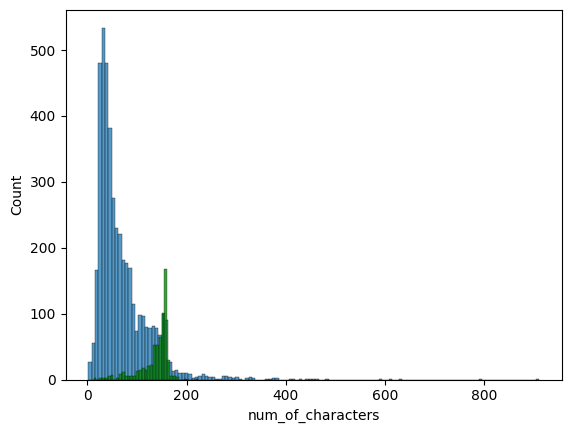

In [231]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_of_characters'])
sns.histplot(df[df['target']==1]['num_of_characters'],color='green')

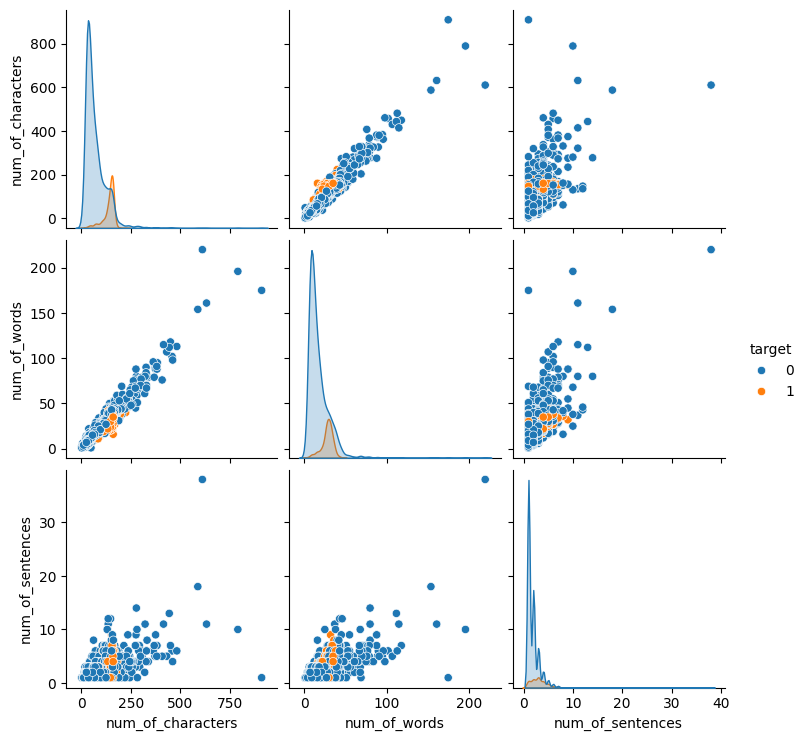

In [232]:
# let's check relation between cols
sns.pairplot(df,hue="target")

outliers exists

<Axes: >

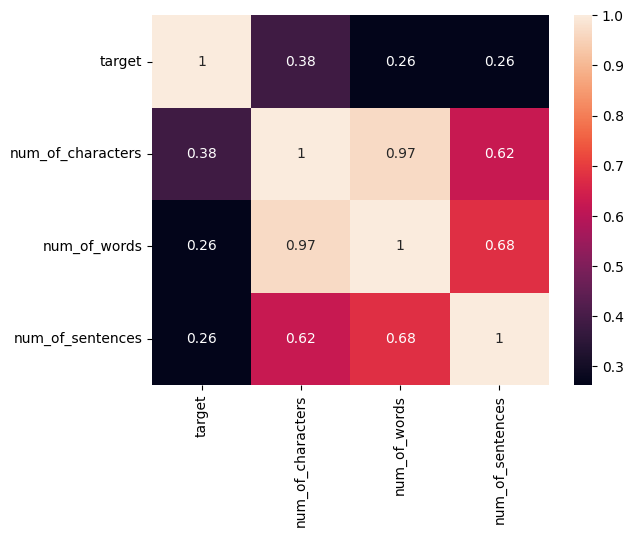

In [233]:
#co-relations
sns.heatmap(df.corr(numeric_only=True), annot=True)

there is high co relation btw number of charcaters and number of words, we have to choose only one col number of characters for training model

**Data Preprocessing** - text preprocessing includes - lower case,Tokenization,removing special charcacters,removing stop words and punctations,stemming

In [234]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [235]:
stop_words = set(stopwords.words('english'))   # already defined above — reuse it

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stop_words and i not in string.punctuation:  # ✅ use the set, not stopwords.words() each time
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [236]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_of_characters,num_of_words,num_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Model building**

In [237]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['transformed_text']
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=3000)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [238]:
print("X_train shape:", X_train.shape)   
print("X_test shape:", X_test.shape)

X_train shape: (4135, 3000)
X_test shape: (1034, 3000)


In [239]:

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [240]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [241]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

In [242]:
print("Accuracy:",accuracy)
print("precision:",precision)

Accuracy: 0.9729206963249516
precision: 0.8601398601398601


In [250]:
from sklearn.metrics import recall_score, f1_score

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Recall: 0.9389312977099237
F1 Score: 0.8978102189781022


In [243]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       903
           1       0.86      0.94      0.90       131

    accuracy                           0.97      1034
   macro avg       0.93      0.96      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [248]:
import seaborn as sns

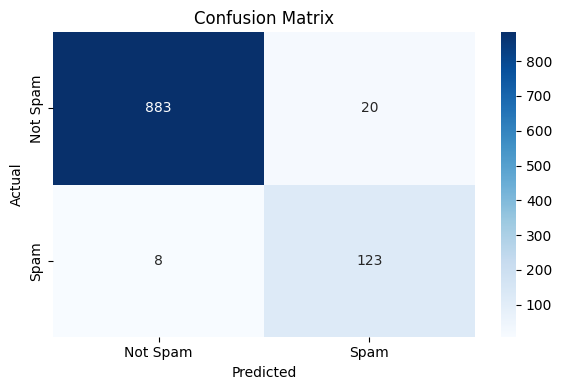

In [249]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [254]:
from sklearn.metrics import roc_curve, auc

In [255]:
# get probability scores
y_proba = lr.predict_proba(X_test)[:, 1]

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [256]:
auc_score = auc(fpr, tpr)

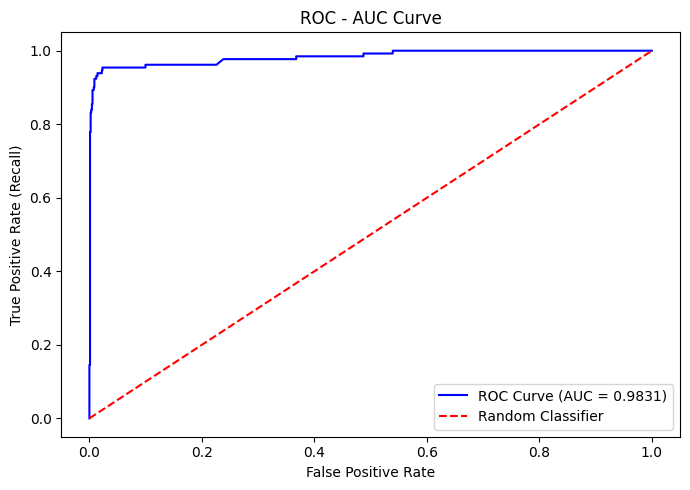

In [257]:
# plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.title('ROC - AUC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.show()

**Testing Model**

In [244]:

# Test Case 1: Clear spam message
new_msg1 = ["FREE entry WIN cash prize call now 08712345"]
msg1_transformed = tfidf.transform(new_msg1)
y_pred1 = lr.predict(msg1_transformed)
print("Spam" if y_pred1[0] == 1 else "Not Spam")

Spam


In [245]:
# Test Case 2: Clear not spam message
new_msg2 = ["Hey are we meeting for lunch tomorrow?"]
msg2_transformed = tfidf.transform(new_msg2)
y_pred2 = lr.predict(msg2_transformed)
print("Spam" if y_pred2[0] == 1 else "Not Spam")

Not Spam


In [246]:
# Test Case 3: From dataset - known spam
new_msg3 = ["WINNER!! As a valued network customer you have been selected to receivea prize reward!"]
msg3_transformed = tfidf.transform(new_msg3)
y_pred3 = lr.predict(msg3_transformed)
print( "Spam" if y_pred3[0] == 1 else "Not Spam")

Spam


**WORK FLOW**

Dataset Collection → Data Cleaning & Removing Unnecessary Columns → Exploratory Data Analysis (EDA) → Text Preprocessing (tokenization, stopword removal, stemming) → Feature Extraction (TF-IDF/Vectorization) → Train-Test Split → Logistic Regression Model Training → Prediction → Model Evaluation (accuracy, confusion matrix, etc.) → Result Analysis & Conclusion.

**conclusion: High accuracy does not always mean better performance, especially with imbalanced datasets. Proper evaluation is important to ensure the model learns meaningful patterns instead of favoring the majority class.**